 Amazon Product Recommendation System vedant Tiwari
**Content-Based Filtering using Text (SBERT) + Image (CLIP/ViT) Embeddings**

---
### Pipeline Overview
1. Load & clean Amazon product data
2. Download & cache product images
3. Extract text embeddings (Sentence-BERT)
4. Extract image embeddings (CLIP ViT-B/32)
5. Fuse features with configurable alpha weighting
6. Build similarity index (cosine + optional FAISS)
7. Recommend top-K products with image display

**Modes:**  
- `TEST_MODE = True` → ~500 samples, runs in < 5 min  
- `TEST_MODE = False` → 50k–100k samples, ~30–40 min on RTX 4060

## 0. Setup & Configuration

In [32]:
# ─── Install dependencies (run once) ───────────────────────────────────────────
# Uncomment if running for the first time
# !pip install sentence-transformers transformers torch torchvision Pillow requests tqdm faiss-cpu kagglehub
# For GPU FAISS: !pip install faiss-gpu

In [33]:
import os
import re
import pickle
import random
import warnings
import hashlib
from pathlib import Path
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import requests
from tqdm.auto import tqdm

import torch
from torch import nn
from torchvision import transforms
from sentence_transformers import SentenceTransformer
from transformers import CLIPProcessor, CLIPModel

warnings.filterwarnings('ignore')
tqdm.pandas()

# ─── FAISS (optional, with graceful fallback) ───────────────────────────────────
try:
    import faiss
    FAISS_AVAILABLE = True
    print("✅ FAISS available — will use for fast similarity search")
except ImportError:
    FAISS_AVAILABLE = False
    print("⚠️  FAISS not found — falling back to cosine similarity (numpy)")

⚠️  FAISS not found — falling back to cosine similarity (numpy)


In [34]:
# ─── GLOBAL CONFIGURATION ──────────────────────────────────────────────────────

# 🔧 Pipeline mode
TEST_MODE = False          # True → ~500 samples | False → full run (50k–100k)

# 🔧 Sample sizes
TEST_SAMPLE_SIZE   = 500
FULL_SAMPLE_SIZE   = 75_000      # Adjust based on VRAM (RTX 4060 = 8GB)

# 🔧 Feature fusion weight  (1.0 = text only, 0.0 = image only)
ALPHA = 0.5

# 🔧 Models
SBERT_MODEL = "all-MiniLM-L6-v2"          # Fast, 384-dim text embeddings
CLIP_MODEL  = "openai/clip-vit-base-patch32"  # 512-dim image+text embeddings

# 🔧 Batch sizes (tune for your GPU)
TEXT_BATCH_SIZE  = 256 if not TEST_MODE else 64
IMAGE_BATCH_SIZE = 64  if not TEST_MODE else 16

# 🔧 Image download settings
IMAGE_CACHE_DIR  = Path("image_cache")
EMBEDDING_DIR    = Path("embeddings")
MAX_IMAGE_WORKERS = 8     # Parallel download threads
IMAGE_TIMEOUT     = 5     # seconds per request
IMAGE_SIZE        = (224, 224)

# 🔧 Paths
IMAGE_CACHE_DIR.mkdir(exist_ok=True)
EMBEDDING_DIR.mkdir(exist_ok=True)

# ─── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🚀 GPU: {gpu_name} ({vram_gb:.1f} GB VRAM)")
else:
    print("💻 Running on CPU — consider enabling GPU for full mode")

print(f"\n📋 Config:")
print(f"   Mode       : {'TEST (500 samples)' if TEST_MODE else f'FULL ({FULL_SAMPLE_SIZE:,} samples)'}")
print(f"   Alpha      : {ALPHA} (text) | {1-ALPHA} (image)")
print(f"   SBERT      : {SBERT_MODEL}")
print(f"   CLIP       : {CLIP_MODEL}")
print(f"   Device     : {DEVICE}")

🚀 GPU: NVIDIA GeForce RTX 4060 Laptop GPU (8.6 GB VRAM)

📋 Config:
   Mode       : FULL (75,000 samples)
   Alpha      : 0.5 (text) | 0.5 (image)
   SBERT      : all-MiniLM-L6-v2
   CLIP       : openai/clip-vit-base-patch32
   Device     : cuda


## 1. Data Loading & Preprocessing

In [35]:
# ─── Load dataset ──────────────────────────────────────────────────────────────
# Option A: via kagglehub
try:
    import kagglehub
    DATASET_PATH = kagglehub.dataset_download("asaniczka/amazon-products-dataset-2023-1-4m-products")
    products_csv   = os.path.join(DATASET_PATH, "amazon_products.csv")
    categories_csv = os.path.join(DATASET_PATH, "amazon_categories.csv")
    print(f"📂 Dataset path: {DATASET_PATH}")
except Exception as e:
    # Option B: provide path manually
    print(f"kagglehub failed: {e}")
    print("Set DATASET_PATH manually below:")
    DATASET_PATH   = "Dataset"     # ← edit if needed
    products_csv   = os.path.join(DATASET_PATH, "amazon_products.csv")
    categories_csv = os.path.join(DATASET_PATH, "amazon_categories.csv")

kagglehub failed: No module named 'kagglehub'
Set DATASET_PATH manually below:


In [36]:
def load_and_clean_products(csv_path: str, categories_path: str) -> pd.DataFrame:
    """
    Load amazon_products.csv + amazon_categories.csv, merge, and clean.
    Returns a clean DataFrame ready for feature extraction.
    """
    print("📥 Loading products...")
    # Load in chunks if the file is large to avoid OOM
    cols = ["asin", "title", "imgUrl", "category_id", "stars", "price", "reviews"]
    df = pd.read_csv(csv_path, usecols=cols, low_memory=False)
    print(f"   Raw rows: {len(df):,}")

    # ── Drop rows with missing critical fields ──
    df = df.dropna(subset=["asin", "title", "imgUrl"])

    # ── Remove duplicate ASINs ──
    df = df.drop_duplicates(subset="asin").reset_index(drop=True)

    # ── Filter rows with invalid / placeholder image URLs ──
    df = df[df["imgUrl"].str.startswith("http", na=False)]

    # ── Clean titles ──
    df["title_clean"] = (
        df["title"]
        .str.strip()
        .str.replace(r"[^\w\s,\-\.&'\"]", " ", regex=True)  # remove weird chars
        .str.replace(r"\s+", " ", regex=True)                # collapse spaces
        .str[:256]                                            # cap length
    )

    # ── Fill numeric columns ──
    df["stars"]   = pd.to_numeric(df["stars"],   errors="coerce").fillna(0)
    df["price"]   = pd.to_numeric(df["price"],   errors="coerce").fillna(0)
    df["reviews"] = pd.to_numeric(df["reviews"], errors="coerce").fillna(0)

    # ── Merge category names ──
    try:
        cats = pd.read_csv(categories_path)[["id", "category_name"]]
        cats = cats.rename(columns={"id": "category_id"})
        df = df.merge(cats, on="category_id", how="left")
        df["category_name"] = df["category_name"].fillna("Unknown")
    except Exception:
        df["category_name"] = "Unknown"

    print(f"   Clean rows: {len(df):,}")
    return df


df_all = load_and_clean_products(products_csv, categories_csv)
df_all.head(3)

📥 Loading products...
   Raw rows: 1,426,337
   Clean rows: 1,426,299


,asin,title,imgUrl,stars,reviews,price,category_id,title_clean,category_name
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,4.5,0,139.99,104,"Sion Softside Expandable Roller Luggage, Black...",Suitcases
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,4.5,0,169.99,104,Luggage Sets Expandable PC ABS Durable Suitcas...,Suitcases
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,4.6,0,365.49,104,Platinum Elite Softside Expandable Checked Lug...,Suitcases


In [37]:
# ─── Sample based on mode ──────────────────────────────────────────────────────
SAMPLE_SIZE = TEST_SAMPLE_SIZE if TEST_MODE else FULL_SAMPLE_SIZE
SAMPLE_SIZE = min(SAMPLE_SIZE, len(df_all))

df = df_all.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"\n✅ Working with {len(df):,} products")
print(df[["asin", "title_clean", "stars", "price", "category_name"]].head())


✅ Working with 75,000 products
         asin                                        title_clean  stars  \
0  B084BQD4RC  Konny Baby Carrier Elastech Carrier Wrap, Easy...    3.8   
1  B09ZTLFDF5  Gllquen Baby Bassinet Sheets 4 Pack, Breathabl...    4.6   
2  B09NZMVJXB  ASCOMY Gold Fidget Spinner Ring for Relieving ...    4.0   
3  B0B99S66BQ  Tudomro 200 Pcs Christmas Charms for Jewelry M...    4.8   
4  B07B4ZLLH6  Aluminum GT2 Timing Belt Pulley 60 Tooth 60T 5...    5.0   

   price                category_name  
0  49.99             Baby Travel Gear  
1  17.99                      Bedding  
2  12.99    Novelty Toys & Amusements  
3  19.99     Beading & Jewelry Making  
4   4.16  Power Transmission Products  


## 2. Image Downloading & Caching

In [38]:
def url_to_cache_path(url: str) -> Path:
    """Map a URL to a stable local file path using its MD5 hash."""
    h = hashlib.md5(url.encode()).hexdigest()
    return IMAGE_CACHE_DIR / f"{h}.jpg"


def download_image(url: str, save_path: Path) -> bool:
    """
    Download an image from `url` to `save_path`.
    Returns True on success, False on failure.
    Skips download if file already exists (cache hit).
    """
    if save_path.exists():          # cache hit
        return True
    try:
        resp = requests.get(url, timeout=IMAGE_TIMEOUT,
                            headers={"User-Agent": "Mozilla/5.0"})
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img.save(save_path, format="JPEG", quality=85)
        return True
    except Exception:
        return False


def batch_download_images(df: pd.DataFrame) -> pd.DataFrame:
    """
    Download all product images in parallel.
    Adds 'img_path' column (local path or None if download failed).
    """
    urls       = df["imgUrl"].tolist()
    save_paths = [url_to_cache_path(u) for u in urls]

    results = {}
    with ThreadPoolExecutor(max_workers=MAX_IMAGE_WORKERS) as executor:
        futures = {executor.submit(download_image, url, path): i
                   for i, (url, path) in enumerate(zip(urls, save_paths))}
        for future in tqdm(as_completed(futures), total=len(futures),
                           desc="📸 Downloading images"):
            idx    = futures[future]
            ok     = future.result()
            results[idx] = str(save_paths[idx]) if ok else None

    df = df.copy()
    df["img_path"] = [results[i] for i in range(len(df))]

    n_ok   = df["img_path"].notna().sum()
    n_fail = df["img_path"].isna().sum()
    print(f"   ✅ Downloaded/cached: {n_ok:,} | ❌ Failed: {n_fail:,}")
    return df


df = batch_download_images(df)

# ── Keep only rows where image download succeeded ──
df = df[df["img_path"].notna()].reset_index(drop=True)
print(f"   Remaining products after image filter: {len(df):,}")

📸 Downloading images: 100%|██████████| 75000/75000 [40:53<00:00, 30.57it/s]  


   ✅ Downloaded/cached: 74,973 | ❌ Failed: 27
   Remaining products after image filter: 74,973


## 3. Text Feature Extraction (Sentence-BERT)

In [39]:
TEXT_EMB_CACHE = EMBEDDING_DIR / f"text_embeddings_{len(df)}.npy"

def extract_text_embeddings(
    titles: list[str],
    model_name: str = SBERT_MODEL,
    batch_size: int = TEXT_BATCH_SIZE,
    cache_path: Path = TEXT_EMB_CACHE,
) -> np.ndarray:
    """
    Generate L2-normalised Sentence-BERT embeddings for a list of titles.
    Results are cached to disk; subsequent calls load from cache.

    Returns: float32 array of shape (N, embedding_dim)
    """
    if cache_path.exists():
        print(f"📂 Loading cached text embeddings from {cache_path}")
        return np.load(cache_path)

    print(f"🔤 Encoding {len(titles):,} titles with {model_name}...")
    model = SentenceTransformer(model_name, device=str(DEVICE))

    embeddings = model.encode(
        titles,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,   # L2 normalise for cosine similarity
        convert_to_numpy=True,
    ).astype(np.float32)

    np.save(cache_path, embeddings)
    print(f"   💾 Saved to {cache_path} | Shape: {embeddings.shape}")
    return embeddings


text_embeddings = extract_text_embeddings(df["title_clean"].tolist())
print(f"\n✅ Text embeddings shape: {text_embeddings.shape}")

🔤 Encoding 74,973 titles with all-MiniLM-L6-v2...


Batches: 100%|██████████| 293/293 [00:23<00:00, 12.42it/s]


   💾 Saved to embeddings\text_embeddings_74973.npy | Shape: (74973, 384)

✅ Text embeddings shape: (74973, 384)


## 4. Image Feature Extraction (CLIP ViT-B/32)

In [40]:
IMAGE_EMB_CACHE = EMBEDDING_DIR / f"image_embeddings_{len(df)}.npy"

# ── CLIP image transform ────────────────────────────────────────────────────────
CLIP_TRANSFORM = transforms.Compose([
    transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275,  0.40821073],
        std =[0.26862954, 0.26130258, 0.27577711],
    ),
])


def load_image_tensor(img_path: str) -> torch.Tensor | None:
    """Load an image from disk and return a (3, H, W) preprocessed tensor."""
    try:
        img = Image.open(img_path).convert("RGB")
        return CLIP_TRANSFORM(img)
    except Exception:
        return None


def extract_image_embeddings(
    img_paths: list[str],
    model_name: str = CLIP_MODEL,
    batch_size: int = IMAGE_BATCH_SIZE,
    cache_path: Path = IMAGE_EMB_CACHE,
) -> np.ndarray:
    """
    Extract L2-normalised CLIP image embeddings.
    Broken/missing images get a zero-vector (will be ignored downstream).
    Results are cached to disk.

    Returns: float32 array of shape (N, embedding_dim)
    """
    if cache_path.exists():
        print(f"📂 Loading cached image embeddings from {cache_path}")
        return np.load(cache_path)

    print(f"🖼️  Encoding {len(img_paths):,} images with CLIP...")
    clip_model = CLIPModel.from_pretrained(
    model_name,
    use_safetensors=True       # ← avoids torch.load entirely
    ).to(DEVICE)
    clip_model.eval()

    dim        = clip_model.config.projection_dim  # 512 for ViT-B/32
    embeddings = np.zeros((len(img_paths), dim), dtype=np.float32)

    with torch.no_grad():
        for start in tqdm(range(0, len(img_paths), batch_size),
                          desc="🖼️  Image batches"):
            batch_paths = img_paths[start : start + batch_size]
            tensors = []
            valid_indices = []

            for j, p in enumerate(batch_paths):
                t = load_image_tensor(p)
                if t is not None:
                    tensors.append(t)
                    valid_indices.append(j)

            if not tensors:
                continue

            batch_tensor = torch.stack(tensors).to(DEVICE)  # (B, 3, H, W)
            feats = clip_model.get_image_features(pixel_values=batch_tensor)
            # L2 normalise
            feats = feats / feats.norm(dim=-1, keepdim=True)
            feats = feats.cpu().numpy().astype(np.float32)

            for local_j, global_j in enumerate(valid_indices):
                embeddings[start + global_j] = feats[local_j]

    del clip_model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    np.save(cache_path, embeddings)
    print(f"   💾 Saved to {cache_path} | Shape: {embeddings.shape}")
    return embeddings


image_embeddings = extract_image_embeddings(df["img_path"].tolist())
print(f"\n✅ Image embeddings shape: {image_embeddings.shape}")

🖼️  Encoding 74,973 images with CLIP...


🖼️  Image batches: 100%|██████████| 1172/1172 [06:05<00:00,  3.21it/s]


   💾 Saved to embeddings\image_embeddings_74973.npy | Shape: (74973, 512)

✅ Image embeddings shape: (74973, 512)


## 5. Feature Fusion

In [41]:
def fuse_embeddings(
    text_embs: np.ndarray,
    image_embs: np.ndarray,
    alpha: float = ALPHA,
) -> np.ndarray:
    """
    Fuse text and image embeddings via weighted sum, then re-normalise.

    Args:
        text_embs  : (N, D_t)  L2-normalised text embeddings
        image_embs : (N, D_i)  L2-normalised image embeddings (may be diff dim)
        alpha      : weight for text (1-alpha for image)

    Strategy:
        If text_dim != image_dim, concatenate and re-normalise.
        If same dim, use weighted sum.

    Returns: float32 array of shape (N, D_fused), L2-normalised
    """
    assert text_embs.shape[0] == image_embs.shape[0], "Mismatch in sample count"
    assert 0.0 <= alpha <= 1.0, "alpha must be in [0, 1]"

    if text_embs.shape[1] == image_embs.shape[1]:
        # Same dimensionality → weighted sum
        fused = alpha * text_embs + (1.0 - alpha) * image_embs
    else:
        # Different dims → scale each by sqrt(weight) then concat
        # This preserves the intended contribution to the Euclidean norm
        t_scaled = np.sqrt(alpha)         * text_embs
        i_scaled = np.sqrt(1.0 - alpha)   * image_embs
        fused    = np.concatenate([t_scaled, i_scaled], axis=1)

    # L2 re-normalise so cosine similarity = dot product
    norms = np.linalg.norm(fused, axis=1, keepdims=True).clip(min=1e-10)
    fused = (fused / norms).astype(np.float32)
    return fused


fused_embeddings = fuse_embeddings(text_embeddings, image_embeddings, alpha=ALPHA)
print(f"✅ Fused embeddings shape : {fused_embeddings.shape}")
print(f"   Alpha = {ALPHA} (text), {1-ALPHA} (image)")

✅ Fused embeddings shape : (74973, 896)
   Alpha = 0.5 (text), 0.5 (image)


## 6. Similarity Index

In [42]:
# ─── Build FAISS index (or fall back to numpy cosine) ──────────────────────────

class SimilarityIndex:
    """
    Unified similarity index supporting FAISS (fast) or numpy (fallback).
    Embeddings must be L2-normalised; inner product == cosine similarity.
    """

    def __init__(self, embeddings: np.ndarray, use_faiss: bool = FAISS_AVAILABLE):
        self.embeddings = embeddings
        self.n, self.d  = embeddings.shape
        self.use_faiss  = use_faiss and FAISS_AVAILABLE

        if self.use_faiss:
            self._build_faiss()
        else:
            print("📐 Using numpy cosine similarity")

    def _build_faiss(self):
        print(f"⚡ Building FAISS IndexFlatIP ({self.n:,} × {self.d})...")
        self.index = faiss.IndexFlatIP(self.d)  # inner product on L2-normed = cosine
        self.index.add(self.embeddings)
        print(f"   Index size: {self.index.ntotal:,}")

    def query(self, query_vec: np.ndarray, top_k: int = 10) -> tuple[np.ndarray, np.ndarray]:
        """
        Find top_k most similar items.
        Args:
            query_vec : (D,) or (1, D) query embedding
            top_k     : number of results (excludes the query itself)
        Returns:
            scores (top_k,), indices (top_k,)
        """
        q = query_vec.reshape(1, -1).astype(np.float32)

        if self.use_faiss:
            scores, indices = self.index.search(q, top_k + 1)  # +1 for self
            scores, indices = scores[0], indices[0]
        else:
            # numpy batch cosine (embeddings already L2-normed)
            scores  = (self.embeddings @ q.T).squeeze()        # (N,)
            indices = np.argsort(-scores)[:top_k + 1]          # descending
            scores  = scores[indices]

        return scores, indices


# Build index
index = SimilarityIndex(fused_embeddings)
print("✅ Similarity index ready")

📐 Using numpy cosine similarity
✅ Similarity index ready


## 7. Recommendation Engine

In [43]:
# ─── Build ASIN → row-index lookup ─────────────────────────────────────────────
asin_to_idx = {asin: i for i, asin in enumerate(df["asin"])}


def recommend(
    product_id: str,
    top_k: int = 5,
    show_images: bool = True,
    alpha_override: float | None = None,
) -> pd.DataFrame:
    """
    Return top-K product recommendations for a given ASIN.

    Args:
        product_id     : Amazon ASIN string
        top_k          : number of recommendations to return
        show_images    : display a matplotlib grid of product images
        alpha_override : if set, rebuilds fused embedding on-the-fly with this alpha

    Returns:
        DataFrame with columns: asin, title, category_name, stars, price, score
    """
    if product_id not in asin_to_idx:
        raise ValueError(f"ASIN '{product_id}' not found in dataset. "
                         f"Try one of: {df['asin'].sample(5).tolist()}")

    query_idx = asin_to_idx[product_id]

    # ── Optionally recompute fused embedding with a different alpha ──
    if alpha_override is not None and 0.0 <= alpha_override <= 1.0:
        q_text  = text_embeddings[query_idx]
        q_image = image_embeddings[query_idx]
        query_vec = fuse_embeddings(
            q_text[np.newaxis],
            q_image[np.newaxis],
            alpha=alpha_override,
        ).squeeze()
    else:
        query_vec = fused_embeddings[query_idx]

    # ── Similarity search ──
    scores, indices = index.query(query_vec, top_k=top_k + 5)

    # ── Filter out the query product itself ──
    mask      = indices != query_idx
    indices   = indices[mask][:top_k]
    scores    = scores[mask][:top_k]

    # ── Build result DataFrame ──
    results = df.iloc[indices][["asin", "title_clean", "category_name",
                                 "stars", "price", "img_path"]].copy()
    results["score"] = scores
    results = results.rename(columns={"title_clean": "title"})

    # ── Display ──
    if show_images:
        _display_recommendations(
            query_row=df.iloc[query_idx],
            results=results,
            top_k=top_k,
        )

    return results[["asin", "title", "category_name", "stars", "price", "score"]]


def _load_display_image(img_path: str | None) -> np.ndarray | None:
    """Load an image for matplotlib display; return None on failure."""
    if img_path is None:
        return None
    try:
        return np.array(Image.open(img_path).convert("RGB").resize((200, 200)))
    except Exception:
        return None


def _display_recommendations(query_row: pd.Series,
                              results: pd.DataFrame,
                              top_k: int) -> None:
    """Render query product + top-K recommendations as a matplotlib grid."""
    n_cols  = top_k + 1  # query + recs
    fig, axes = plt.subplots(1, n_cols, figsize=(3.5 * n_cols, 5))
    fig.patch.set_facecolor("#1a1a2e")

    def render_ax(ax, img_arr, title, subtitle, score=None, is_query=False):
        ax.set_facecolor("#16213e")
        if img_arr is not None:
            ax.imshow(img_arr)
        else:
            ax.text(0.5, 0.5, "No Image", ha="center", va="center",
                    color="#888", transform=ax.transAxes)
        ax.axis("off")

        border_color = "#e94560" if is_query else "#0f3460"
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2)

        wrapped = (title[:38] + "…") if len(title) > 40 else title
        ax.set_title(wrapped, color="white", fontsize=8, pad=4, wrap=True)

        lbl = "QUERY" if is_query else f"Score: {score:.3f}"
        ax.set_xlabel(f"{lbl}\n{subtitle}",
                      color="#e94560" if is_query else "#aaa",
                      fontsize=7)

    # ── Query product ──
    render_ax(
        axes[0],
        _load_display_image(query_row.get("img_path")),
        title    = str(query_row.get("title_clean", "")),
        subtitle = str(query_row.get("category_name", "")),
        is_query = True,
    )

    # ── Recommendations ──
    for i, (_, row) in enumerate(results.iterrows()):
        render_ax(
            axes[i + 1],
            _load_display_image(row.get("img_path")),
            title    = str(row["title"]),
            subtitle = str(row["category_name"]),
            score    = float(row["score"]),
        )

    plt.suptitle(f"🛍️ Top-{top_k} Recommendations  |  α={ALPHA}",
                 color="white", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


print("✅ recommend() is ready")

✅ recommend() is ready


## 8. Demo — Top-5 Recommendations

🎯 Query product: [B08XWR6T6V] kathson Hamster Bathroom Gerbil Sand Dry Bath Plastic Container Small Animal Toi


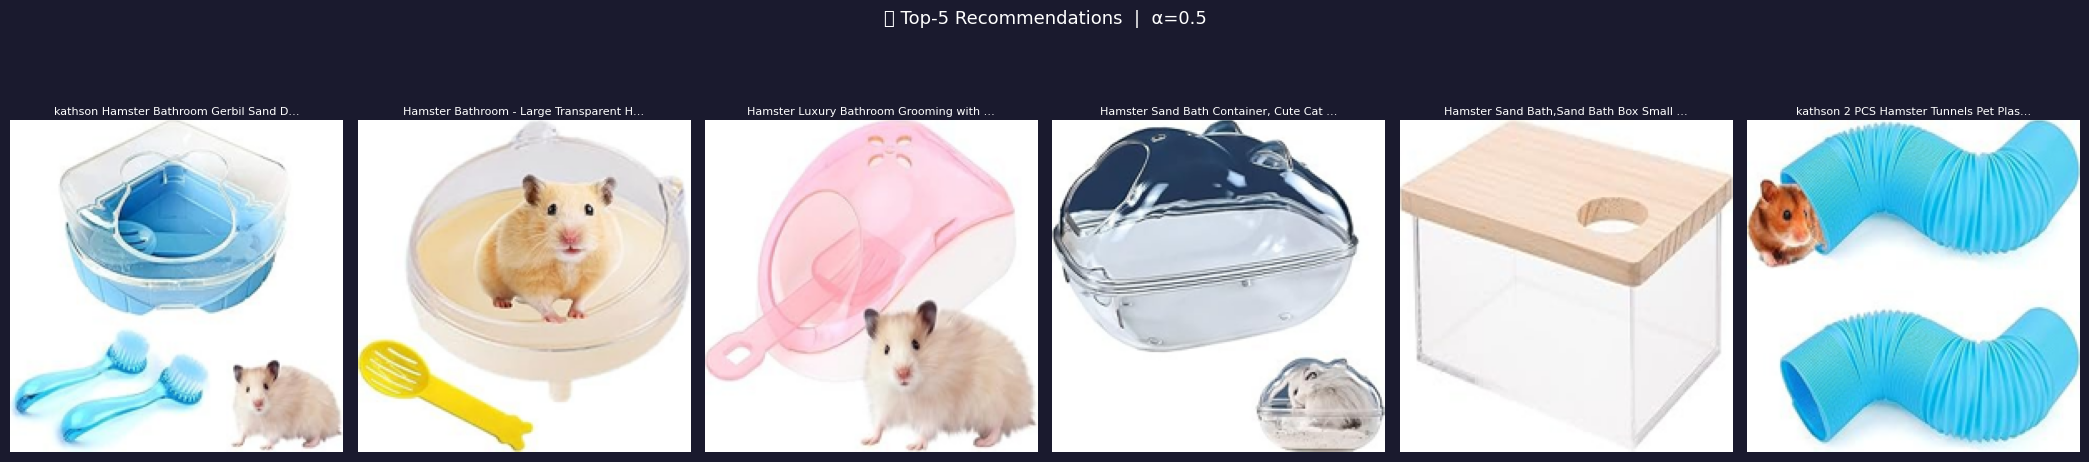


📊 Recommendation Table:


,asin,title,category_name,stars,price,score
26593,B0BNV83Q9N,Hamster Bathroom - Large Transparent Hamster S...,Small Animal Supplies,5.0,13.99,0.794443
46626,B0C3HNN2LW,Hamster Luxury Bathroom Grooming with Lid and ...,Small Animal Supplies,0.0,9.99,0.770651
43309,B0BQVZJZ7D,"Hamster Sand Bath Container, Cute Cat Ears Ham...",Small Animal Supplies,0.0,10.99,0.761937
71926,B09VDH6RM8,"Hamster Sand Bath,Sand Bath Box Small Animal S...",Small Animal Supplies,3.5,10.59,0.760550
43735,B089LXCQY1,kathson 2 PCS Hamster Tunnels Pet Plastic Tube...,Small Animal Supplies,4.3,12.99,0.754003


In [44]:
# ─── Pick a random product and show recommendations ─────────────────────────────
random.seed(99)
random_asin = df.sample(1)["asin"].values[0]
random_title = df.loc[df["asin"] == random_asin, "title_clean"].values[0]
print(f"🎯 Query product: [{random_asin}] {random_title[:80]}")

recs = recommend(random_asin, top_k=5, show_images=True)
print("\n📊 Recommendation Table:")
display(recs)

🎯 Query: Women's Backpack, Brown, U


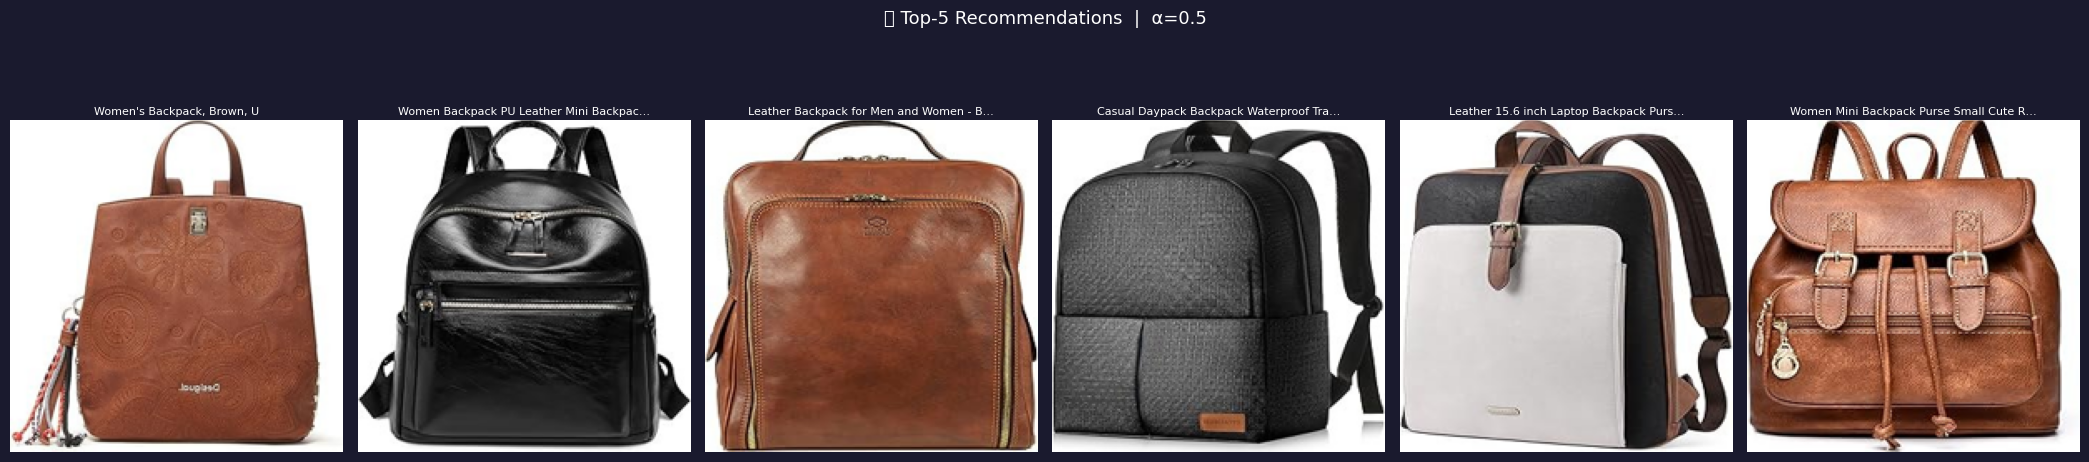

,asin,title,category_name,stars,price,score
2251,B0C2HKVMH1,Women Backpack PU Leather Mini Backpack Purse ...,Women's Handbags,5.0,26.99,0.759272
46906,B017RAR5U8,Leather Backpack for Men and Women - Brown Bus...,Backpacks,4.5,237.00,0.754981
4403,B0C4TRNXRS,Casual Daypack Backpack Waterproof Travel Back...,Laptop Bags,4.2,23.98,0.748117
66296,B0C2CDJB8T,Leather 15.6 inch Laptop Backpack Purse for Wo...,Laptop Bags,4.7,99.99,0.744503
42675,B07QYYC7RK,Women Mini Backpack Purse Small Cute Retro Lea...,Women's Handbags,4.0,15.86,0.742132


In [45]:
# ─── Try a second example with a different product ─────────────────────────────
random_asin2 = df.sample(1, random_state=7)["asin"].values[0]
print(f"🎯 Query: {df.loc[df['asin'] == random_asin2, 'title_clean'].values[0][:80]}")
recs2 = recommend(random_asin2, top_k=5, show_images=True)
display(recs2)

In [46]:
# ─── Experiment: compare recommendations at different alpha values ─────────────
test_asin = df.sample(1, random_state=42)["asin"].values[0]
test_title = df.loc[df["asin"] == test_asin, "title_clean"].values[0]
print(f"🧪 Alpha sweep for: {test_title[:70]}\n")

for alpha_val in [0.0, 0.3, 0.5, 0.7, 1.0]:
    print(f"\n{'─'*60}")
    print(f"   α = {alpha_val}  ({'text only' if alpha_val == 1.0 else 'image only' if alpha_val == 0.0 else f'{int(alpha_val*100)}% text / {int((1-alpha_val)*100)}% image'})")
    recs_alpha = recommend(test_asin, top_k=3,
                           show_images=False, alpha_override=alpha_val)
    print(recs_alpha[["title", "score"]].to_string(index=False))

🧪 Alpha sweep for: Powell Peralta Retro Black Series Flight Skateboard Deck


────────────────────────────────────────────────────────────
   α = 0.0  (image only)
                                                                      title    score
                     SAMSUNG Electronics VCA-RPB71 XAA POWERbot Combo Brush 0.533989
ER3XR with Etymotion Wireless Bluetooth Cable, Black, Model Number ER3XR-BT 0.532070
         500GB Intenso USB3.0 Memory Case 2.5-inch Slim Portable Hard Drive 0.526161

────────────────────────────────────────────────────────────
   α = 0.3  (30% text / 70% image)
                                                                                                                                                                                       title    score
                                     Wooden Fingerboard Complete NW8.0 Maple 6-Layer 360Flip Deck, NW3.0 King Trucks Silvery,NW3.0 Wheels White Genesis Door iii, 100x34mm Standard Concave  0.664326
   

## 10. Embedding Space Visualisation (t-SNE)

In [47]:
# ─── 2D t-SNE of fused embeddings (TEST_MODE only to keep it fast) ─────────────
if TEST_MODE and len(df) <= 1000:
    from sklearn.manifold import TSNE
    import matplotlib.cm as cm

    print("🗺️  Running t-SNE (this takes ~30s on CPU)...")
    tsne    = TSNE(n_components=2, perplexity=30, random_state=42)
    coords  = tsne.fit_transform(fused_embeddings)

    # Encode categories as integers for colouring
    cats    = df["category_name"].astype("category")
    cat_ids = cats.cat.codes.values
    n_cats  = len(cats.cat.categories)
    cmap    = cm.get_cmap("tab20", n_cats)

    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")

    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=cat_ids, cmap=cmap, s=18, alpha=0.75, linewidths=0)

    # Legend (top 10 categories by count)
    top_cats = cats.value_counts().head(10).index.tolist()
    handles  = [
        mpatches.Patch(
            color=cmap(cats.cat.categories.get_loc(c)),
            label=c[:30]
        )
        for c in top_cats
        if c in cats.cat.categories
    ]
    ax.legend(handles=handles, loc="upper right",
              fontsize=6, facecolor="#1a1a2e",
              labelcolor="white", framealpha=0.9)

    ax.set_title("t-SNE of Fused Product Embeddings",
                 color="white", fontsize=14)
    ax.tick_params(colors="#555")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

    plt.tight_layout()
    plt.savefig("tsne_embeddings.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved tsne_embeddings.png")
else:
    print("⏭️  Skipping t-SNE (FULL_MODE or large sample — would be slow)")

⏭️  Skipping t-SNE (FULL_MODE or large sample — would be slow)


## 11. Save Artefacts

In [48]:
# ─── Persist index + metadata for future inference without recomputing ──────────
SAVE_PATH = EMBEDDING_DIR / f"rec_system_{len(df)}.pkl"

payload = {
    "asin_to_idx"       : asin_to_idx,
    "df_meta"           : df[["asin", "title_clean", "category_name",
                               "stars", "price", "img_path"]].copy(),
    "alpha"             : ALPHA,
    "fused_embeddings"  : fused_embeddings,
}

with open(SAVE_PATH, "wb") as f:
    pickle.dump(payload, f)

print(f"💾 Saved recommendation system to {SAVE_PATH}")
print(f"   File size: {SAVE_PATH.stat().st_size / 1e6:.1f} MB")

💾 Saved recommendation system to embeddings\rec_system_74973.pkl
   File size: 285.0 MB


In [49]:
# ─── Loading example (for future inference) ─────────────────────────────────────
def load_recommendation_system(pkl_path: str | Path):
    """
    Load a saved recommendation system and rebuild the similarity index.
    Returns: (df, asin_to_idx, index, fused_embeddings, alpha)
    """
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    idx    = SimilarityIndex(data["fused_embeddings"])
    print(f"✅ Loaded system with {len(data['df_meta']):,} products")
    return (
        data["df_meta"],
        data["asin_to_idx"],
        idx,
        data["fused_embeddings"],
        data["alpha"],
    )

# Verify round-trip load
_ = load_recommendation_system(SAVE_PATH)
print("✅ Round-trip load verified")

📐 Using numpy cosine similarity
✅ Loaded system with 74,973 products
✅ Round-trip load verified


## 12. Summary

| Component | Choice | Notes |
|-----------|--------|-------|
| Text model | `all-MiniLM-L6-v2` | 384-dim, fast, good quality |
| Image model | `clip-vit-base-patch32` | 512-dim, zero-shot generalisation |
| Fusion | Weighted sum + L2-renorm | Configurable via `ALPHA` |
| Similarity | Cosine (FAISS or numpy) | FAISS = 10–100× faster at scale |
| Caching | `.npy` + `.jpg` on disk | Avoids recomputation |
| GPU | Automatic via `torch.cuda` | Both models use GPU if available |

### Tuning Tips
- **ALPHA = 1.0** → pure text matching (good when titles are descriptive)
- **ALPHA = 0.0** → pure visual matching (good for fashion/aesthetics)
- **ALPHA = 0.5** → balanced (default, usually best)
- Increase `FULL_SAMPLE_SIZE` up to ~200k if you have >16GB VRAM
- Switch to `faiss-gpu` for 10× faster search on large corpora
- Swap SBERT model to `all-mpnet-base-v2` for higher accuracy (+~5% but 3× slower)